# 실습 준비 (Set Up)

이 노트북은 deepfake audio detection의 처리 흐름을 순서대로 다룹니다. spoof 음성의 정의, artifact의 발생 위치, countermeasure (CM) 구성, EER을 이용한 평가, 학습에 없던 공격에 대한 generalization 순입니다.

진짜 사람 음성을 bonafide 클래스로 사용하고, spoof 클래스는 vocoder 방식의 resynthesis로 직접 생성합니다. 별도의 anti-spoofing 데이터셋을 내려받지 않고 노트북 전체를 실행하기 위한 구성입니다.

사용 라이브러리는 다음과 같습니다. `transformers`는 사전학습된 self-supervised front-end, `torchaudio`와 `librosa`는 오디오 입출력과 분석, `scikit-learn`은 CM 분류기와 평가 지표를 담당합니다. 모든 오디오의 sample rate는 16 kHz이며, 이는 사전학습된 front-end의 입력 조건입니다.

실행 전 런타임을 GPU로 설정합니다: `런타임 > 런타임 유형 변경 > 하드웨어 가속기 > GPU (T4)`.

In [1]:
%%capture

# 핵심 패키지 설치 (SSL front-end용 transformers + 오디오/ML 도구)
!pip install -U "transformers>=4.40" torchaudio librosa scikit-learn matplotlib soundfile datasets

# 그래프의 한글 라벨 표시를 위한 폰트
!apt-get -qq install -y fonts-nanum

노트북 전체에서 사용할 라이브러리를 import 합니다.

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
import IPython.display as ipd
import matplotlib.font_manager as fm

# matplotlib 한글 폰트 설정 (없으면 기본 폰트 사용)
try:
    fm.fontManager.addfont("/usr/share/fonts/truetype/nanum/NanumGothic.ttf")
    plt.rc("font", family="NanumGothic")
except Exception:
    pass
plt.rc("axes", unicode_minus=False)

연산 장치(device)를 선택하고 sample rate를 고정합니다.

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
SAMPLERATE = 16000
rng = np.random.default_rng(0)

print(f"PyTorch : {torch.__version__}")
print(f"Device  : {device}")
if device == "cpu":
    print("경고: CPU로 실행 중입니다. GPU 런타임으로 바꾸면 훨씬 빠릅니다.")

PyTorch : 2.11.0+cu128
Device  : cuda


# Deepfake Audio Detection 문제 정의

오디오 deepfake는 크게 두 가지 방식으로 생성됩니다. **Text-to-speech (TTS)** 는 텍스트로부터 목표 화자의 음성을 합성하고, **voice conversion (VC)** 는 기존 녹음을 다른 화자의 음성으로 변환합니다. 두 방식 모두 마지막 단계에 *vocoder*가 있으며, vocoder는 중간 표현(주로 mel-spectrogram)을 waveform으로 복원하는 모듈입니다.

mel-spectrogram 변환 과정에서 phase 정보가 손실됩니다. vocoder는 이 정보를 추정해서 복원하며, 복원 결과에는 원본과 다른 성분이 남습니다. 이를 artifact라고 하고, countermeasure (CM) 시스템은 이 artifact를 근거로 판별합니다.

머신러닝 관점에서는 binary classification 문제입니다. 입력 발화에 대해 **bonafide**(진짜 음성)와 **spoof**(합성 또는 변환된 음성) 중 하나를 출력합니다. test 시점의 공격은 일반적으로 train 시점의 공격과 다르며, 특정 vocoder의 artifact에만 맞춰진 탐지기는 이 조건에서 성능이 떨어집니다. 이 항목은 노트북 후반에서 측정합니다.

## Bonafide 음성 불러오기

진짜 사람 녹음을 불러옵니다. 이 음성이 bonafide 클래스가 되며, 동시에 spoof 클래스의 원본으로도 사용됩니다. 같은 음성에서 spoof를 생성하면 두 클래스의 화자, 발화 내용, 녹음 조건이 동일하고 resynthesis 과정만 달라집니다.

spoof 클립을 다른 코퍼스에서 가져올 경우, 분류기가 artifact가 아니라 코퍼스 간 차이를 학습해도 높은 정확도가 나올 수 있습니다.

In [4]:
from datasets import load_dataset

# HuggingFace 예제에서 널리 쓰이는 작은 LibriSpeech 부분집합 (16 kHz, 깨끗한 낭독 음성)
ds = load_dataset("hf-internal-testing/librispeech_asr_dummy", split="validation")

print(f"발화 수 : {len(ds)}")

README.md:   0%|          | 0.00/520 [00:00<?, ?B/s]

clean/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 9.19MB            

clean/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating validation split:   0%|          | 0/73 [00:00<?, ? examples/s]

발화 수 : 73


In [5]:
sample = ds[0]
wav = np.asarray(sample["audio"]["array"], dtype=np.float32)
sr_in = sample["audio"]["sampling_rate"]

if sr_in != SAMPLERATE:
    wav = librosa.resample(wav, orig_sr=sr_in, target_sr=SAMPLERATE)

print(f"sample rate    : {SAMPLERATE}")
print(f"duration (s)   : {len(wav) / SAMPLERATE:.2f}")
print(f"waveform shape : {wav.shape} | dtype : {wav.dtype}")
ipd.display(ipd.Audio(wav, rate=SAMPLERATE))

sample rate    : 16000
duration (s)   : 5.86
waveform shape : (93680,) | dtype : float32


# Spoof 음성 생성

## 세 가지 Resynthesis 공격

전체 TTS 시스템 대신 artifact가 발생하는 단계인 vocoder만 재현합니다. 아래 함수들은 waveform을 입력받아 resynthesis된 waveform을 반환하며, 각각 다른 종류의 artifact를 생성합니다.

`spoof_griffinlim`은 mel-vocoder 방식입니다. mel-spectrogram을 계산하면서 phase를 버리고, 반복적인 phase 추정으로 waveform을 복원합니다. neural vocoder도 동일한 정보 손실 조건에서 동작합니다.

`spoof_phase_random`은 magnitude spectrogram을 유지하고 phase만 난수로 대체합니다. phase 성분만의 영향을 분리해서 관찰하기 위한 구성입니다.

`spoof_mulaw`는 진폭 양자화(quantization) 기반이며, WaveNet 등 autoregressive waveform model에서 발생하는 artifact에 해당합니다. 이 공격은 training set에서 제외하고, 뒤에서 unseen attack으로 사용합니다.

In [6]:
from scipy.signal import lfilter

N_FFT, HOP = 1024, 256


def _match_length(out, ref):
    """공격을 거친 클립 길이를 원본과 정확히 같게 맞춘다 (부족하면 패딩, 남으면 자름)."""
    out = np.asarray(out, dtype=np.float32)
    if len(out) < len(ref):
        out = np.pad(out, (0, len(ref) - len(out)))
    return out[:len(ref)]


def spoof_griffinlim(y, n_mels=80, n_iter=32):
    """Mel-vocoder 방식 공격: waveform -> mel -> waveform (이 과정에서 phase가 버려짐)."""
    mel = librosa.feature.melspectrogram(y=y, sr=SAMPLERATE, n_fft=N_FFT, hop_length=HOP, n_mels=n_mels)
    out = librosa.feature.inverse.mel_to_audio(
        mel, sr=SAMPLERATE, n_fft=N_FFT, hop_length=HOP, n_iter=n_iter
    )
    return _match_length(out, y)


def spoof_phase_random(y):
    """magnitude spectrogram은 그대로 두고 phase만 노이즈로 교체."""
    S = librosa.stft(y, n_fft=N_FFT, hop_length=HOP)
    phase = np.exp(2j * np.pi * rng.random(S.shape))
    out = librosa.istft(np.abs(S) * phase, hop_length=HOP)
    return _match_length(out, y)


def spoof_mulaw(y, bits=6):
    """Autoregressive vocoder 방식 공격: 거친 mu-law 양자화 + 약한 over-smoothing."""
    mu = 2 ** bits - 1
    comp = np.sign(y) * np.log1p(mu * np.abs(y)) / np.log1p(mu)      # mu-law 압축
    q = np.round((comp + 1) / 2 * mu) / mu * 2 - 1                    # `bits` 비트로 양자화
    out = np.sign(q) * np.expm1(np.abs(q) * np.log1p(mu)) / mu        # 복원(expand)
    out = lfilter([0.5, 0.5], [1.0], out)                             # 살짝 뭉개기(over-smoothing)
    return _match_length(out, y)


ATTACKS = {"A01_griffinlim": spoof_griffinlim, "A02_phaserand": spoof_phase_random}
UNSEEN_ATTACK = {"A03_mulaw": spoof_mulaw}

bonafide 클립과 세 가지 spoof 버전을 재생합니다.

In [7]:
clip = wav[:SAMPLERATE * 3]
variants = {"bonafide": clip}
for name, fn in {**ATTACKS, **UNSEEN_ATTACK}.items():
    variants[name] = fn(clip)

for name, y in variants.items():
    print(name)
    ipd.display(ipd.Audio(y, rate=SAMPLERATE))

bonafide


A01_griffinlim


A02_phaserand


A03_mulaw


## Artifact의 발생 위치

네 가지 버전의 spectrogram을 동일한 dB 스케일로 표시합니다. 원본과 비교해 harmonics의 번짐, 고주파 대역의 평탄화, 무음 구간의 에너지 발생 여부를 확인합니다.

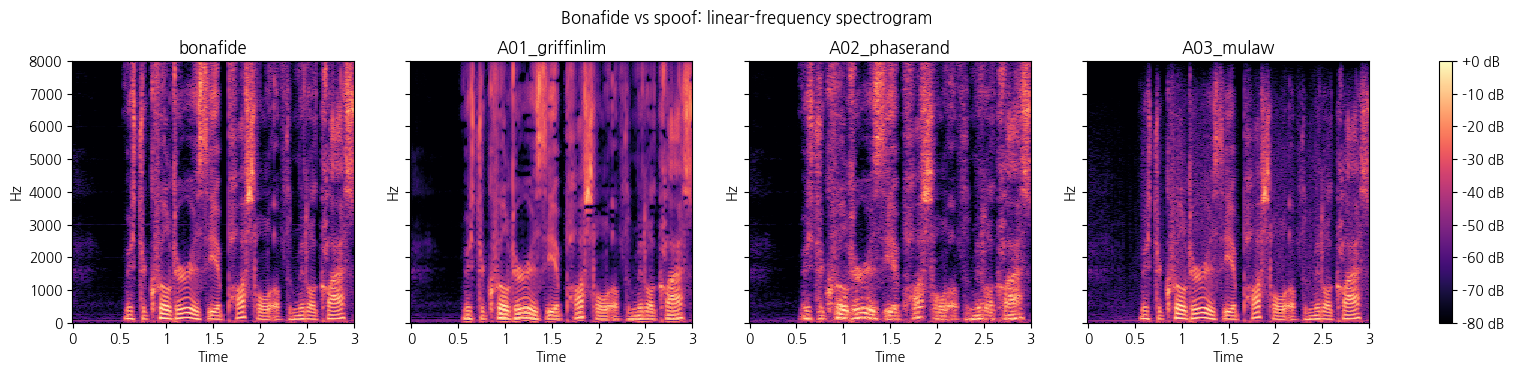

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(18, 3.4), sharey=True)

for ax, (name, y) in zip(axes, variants.items()):
    D = librosa.amplitude_to_db(np.abs(librosa.stft(y, n_fft=N_FFT, hop_length=HOP)), ref=np.max)
    img = librosa.display.specshow(D, sr=SAMPLERATE, hop_length=HOP, x_axis="time", y_axis="hz", ax=ax)
    ax.set(title=name, ylim=(0, 8000))

fig.colorbar(img, ax=axes, format="%+2.0f dB", fraction=0.02)
plt.suptitle("Bonafide vs spoof: linear-frequency spectrogram", y=1.03)
plt.show()

log-power spectrum을 시간 축으로 평균하면 발화 내용이 제거되고 각 공격의 주파수별 특성이 남습니다. 차이는 주로 고주파 대역에 나타납니다. vocoder는 지각 품질에 영향이 큰 저주파를 우선 모델링하고 고주파 대역의 모델링 정확도는 상대적으로 낮습니다.

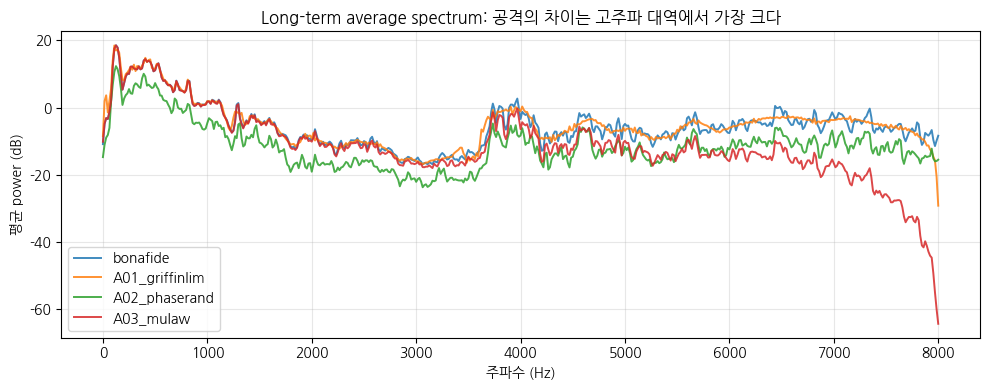

In [9]:
plt.figure(figsize=(10, 4))
freqs = librosa.fft_frequencies(sr=SAMPLERATE, n_fft=N_FFT)

for name, y in variants.items():
    S = np.abs(librosa.stft(y, n_fft=N_FFT, hop_length=HOP)) ** 2
    avg_db = 10 * np.log10(S.mean(axis=1) + 1e-10)
    plt.plot(freqs, avg_db, lw=1.4, label=name, alpha=0.85)

plt.xlabel("주파수 (Hz)")
plt.ylabel("평균 power (dB)")
plt.title("Long-term average spectrum: 공격의 차이는 고주파 대역에서 가장 크다")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Anti-Spoofing 데이터셋 구성

## Bonafide 음성 분할

CM 학습에는 길이가 일정한 짧은 샘플이 다수 필요하므로, 모든 발화를 고정 길이로 분할합니다. anti-spoofing 시스템은 일반적으로 약 4초 단위로 동작하지만, 여기서는 실행 시간을 줄이기 위해 3초를 사용합니다. 대부분이 무음인 구간은 제외합니다. 무음 구간에는 vocoder artifact가 없습니다.

In [10]:
SEG_SEC = 3
SEG_LEN = SEG_SEC * SAMPLERATE
MAX_SEGMENTS = 240      # 노트북이 느리면 이 값을 줄이세요

segments = []
for item in ds:
    y = np.asarray(item["audio"]["array"], dtype=np.float32)
    if item["audio"]["sampling_rate"] != SAMPLERATE:
        y = librosa.resample(y, orig_sr=item["audio"]["sampling_rate"], target_sr=SAMPLERATE)
    for start in range(0, len(y) - SEG_LEN + 1, SEG_LEN):
        seg = y[start:start + SEG_LEN]
        if np.sqrt((seg ** 2).mean()) > 0.005:      # 거의 무음인 조각은 건너뜀
            segments.append(seg)

segments = segments[:MAX_SEGMENTS]
print(f"bonafide 조각 수 : {len(segments)}  (각 {SEG_SEC}초)")

bonafide 조각 수 : 121  (각 3초)


## Spoof 데이터 생성

모든 bonafide 조각을 학습용 공격 두 가지에 각각 적용합니다. 결과적으로 각 spoof 클립은 발화 내용과 화자가 동일한 bonafide 클립과 짝을 이루며, 두 클래스의 차이는 artifact뿐입니다.

In [11]:
from tqdm.auto import tqdm

waveforms, labels, attack_ids = [], [], []

for seg in tqdm(segments, desc="데이터셋 생성"):
    waveforms.append(seg)
    labels.append(0)                 # 0 = bonafide(진짜)
    attack_ids.append("bonafide")
    for name, fn in ATTACKS.items():
        waveforms.append(fn(seg))
        labels.append(1)             # 1 = spoof(가짜)
        attack_ids.append(name)

labels = np.array(labels)
attack_ids = np.array(attack_ids)

print(f"전체 클립 수 : {len(waveforms)}")
print(f"bonafide    : {(labels == 0).sum()}")
print(f"spoof       : {(labels == 1).sum()}")
for a in ATTACKS:
    print(f"  {a} : {(attack_ids == a).sum()}")

데이터셋 생성:   0%|          | 0/121 [00:00<?, ?it/s]

전체 클립 수 : 363
bonafide    : 121
spoof       : 242
  A01_griffinlim : 121
  A02_phaserand : 121


# Countermeasure Front-End

## LFCC

ASVspoof 공식 baseline은 **LFCC** (linear-frequency cepstral coefficients)를 사용합니다. MFCC의 mel scale은 고주파 대역을 압축하는데, artifact는 주로 이 대역에 존재합니다. linear filterbank는 전 대역에 동일한 해상도를 할당합니다.

linear와 mel의 차이를 확인하기 위해 filterbank를 직접 구현합니다. filter 40개, cepstral coefficient 20개를 사용하고, spectrum의 시간 변화를 반영하기 위해 delta와 delta-delta를 추가합니다.

LFCC는 magnitude spectrum에서 계산되며 phase 정보를 사용하지 않습니다. 따라서 magnitude를 유지하고 phase만 변경하는 `A02_phaserand`에 대해서는 원본과 유사한 특징값이 나옵니다. 이 한계는 뒤의 평가 결과에서 확인합니다.

In [12]:
from scipy.fftpack import dct


def linear_filterbank(sr=SAMPLERATE, n_fft=N_FFT, n_filters=40):
    """Hz 축에서 균일한 간격의 삼각 필터 (mel filterbank와 다른 점)."""
    pts = np.linspace(0, sr / 2, n_filters + 2)
    bins = np.floor((n_fft + 1) * pts / sr).astype(int)
    fb = np.zeros((n_filters, n_fft // 2 + 1))
    for m in range(1, n_filters + 1):
        l, c, r = bins[m - 1], bins[m], bins[m + 1]
        for k in range(l, c):
            fb[m - 1, k] = (k - l) / max(c - l, 1)
        for k in range(c, min(r, fb.shape[1])):
            fb[m - 1, k] = (r - k) / max(r - c, 1)
    return fb


FB = linear_filterbank()


def feat_lfcc(y, n_coef=20):
    S = np.abs(librosa.stft(y, n_fft=N_FFT, hop_length=HOP)) ** 2
    lin = np.log(FB @ S + 1e-10)                 # linear-frequency log filterbank 에너지
    c = dct(lin, axis=0, type=2, norm="ortho")[:n_coef]
    d = librosa.feature.delta(c)                 # 1차 delta (시간 변화량)
    dd = librosa.feature.delta(c, order=2)       # 2차 delta
    f = np.concatenate([c, d, dd], axis=0)
    return np.concatenate([f.mean(axis=1), f.std(axis=1)])   # 시간 축으로 pooling

## SSL Front-End

최근 anti-spoofing 연구는 수작업 cepstrum 대신 self-supervised 표현을 사용합니다. wav2vec 2.0 등은 진짜 음성만으로 사전학습되었으며, 합성 음성은 이 표현 공간에서 진짜 음성과 다른 위치에 분포합니다.

모델은 freeze 상태로 사용하고, frame 단위 표현을 mean과 standard deviation으로 pooling 합니다. vocoder 출력은 시간에 따른 변화가 진짜 음성보다 작은 경향이 있어, standard deviation이 판별 정보를 포함합니다.

In [13]:
from transformers import AutoFeatureExtractor, Wav2Vec2Model

W2V_NAME = "facebook/wav2vec2-base"
processor = AutoFeatureExtractor.from_pretrained(W2V_NAME)
w2v = Wav2Vec2Model.from_pretrained(W2V_NAME).to(device).eval()

for p in w2v.parameters():
    p.requires_grad_(False)

print(f"front-end 파라미터 수 : {sum(p.numel() for p in w2v.parameters()) / 1e6:.1f} M (frozen)")

preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.84k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  380MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

[transformers] Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
project_hid.bias             | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors: reconstructing file:   0%|          |  0.00B /  380MB            

model.safetensors: downloading bytes:           |  0.00B            

front-end 파라미터 수 : 94.4 M (frozen)


In [14]:
SSL_LAYER = 5      # 중간 layer. 연습 문제에서 다른 층도 시도해 보세요


@torch.no_grad()
def feat_ssl(y, layer=SSL_LAYER):
    x = processor(y, sampling_rate=SAMPLERATE, return_tensors="pt").input_values.to(device)
    h = w2v(x, output_hidden_states=True).hidden_states[layer][0]     # [T, 768]
    return torch.cat([h.mean(0), h.std(0)]).cpu().numpy()             # mean + std pooling -> 1536차원

두 front-end를 전체 클립에 적용합니다. GPU 기준 수 분이 소요되며, 위의 `MAX_SEGMENTS`를 줄이면 단축됩니다.

In [15]:
X_lfcc, X_ssl = [], []
for y in tqdm(waveforms, desc="feature 추출"):
    X_lfcc.append(feat_lfcc(y))
    X_ssl.append(feat_ssl(y))

X_lfcc = np.stack(X_lfcc)
X_ssl = np.stack(X_ssl)

print("LFCC features :", X_lfcc.shape)
print("SSL  features :", X_ssl.shape)

feature 추출:   0%|          | 0/363 [00:00<?, ?it/s]

LFCC features : (363, 120)
SSL  features : (363, 1536)


# Countermeasure 학습 및 평가

## Equal Error Rate (EER)

이 문제에서는 accuracy 대신 **equal error rate (EER)** 를 사용합니다. decision threshold에 따라 두 종류의 오류가 반대 방향으로 변하고, 실제 시스템은 요구 조건에 맞춰 threshold를 선택하기 때문입니다. EER은 false acceptance rate(spoof를 bonafide로 판정)와 false rejection rate(bonafide를 spoof로 판정)가 같아지는 지점의 오류율이며, 값이 낮을수록 성능이 높습니다. 무작위 판별의 EER은 50%입니다.

train/test 분할은 클립 단위가 아니라 segment 단위로 수행합니다. 이렇게 하지 않으면 bonafide 조각과 그로부터 생성된 spoof 클립이 train과 test에 나뉘어 들어가고, 분류기가 동일 원본을 참조할 수 있습니다.

In [16]:
from sklearn.metrics import roc_curve


def compute_eer(y_true, scores):
    """scores : 값이 클수록 spoof일 가능성이 높다는 뜻."""
    fpr, tpr, thr = roc_curve(y_true, scores)
    fnr = 1 - tpr
    i = np.nanargmin(np.abs(fnr - fpr))
    return (fpr[i] + fnr[i]) / 2, thr[i]

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# 그룹 인덱스: 각 클립이 어느 bonafide 조각에서 왔는지 (조각과 그 쌍둥이들은 같은 번호)
groups = np.repeat(np.arange(len(segments)), 1 + len(ATTACKS))

train_seg, test_seg = train_test_split(np.arange(len(segments)), test_size=0.3, random_state=0)
is_train = np.isin(groups, train_seg)

print(f"train clips : {is_train.sum()}   test clips : {(~is_train).sum()}")

train clips : 252   test clips : 111


In [18]:
def run_cm(X, name):
    clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000))
    clf.fit(X[is_train], labels[is_train])

    scores = clf.predict_proba(X[~is_train])[:, 1]      # P(spoof) = spoof일 확률
    acc = clf.score(X[~is_train], labels[~is_train])
    eer, thr = compute_eer(labels[~is_train], scores)

    print(f"{name:>6s} : accuracy = {acc * 100:5.1f}%   EER = {eer * 100:5.2f}%")
    return {"clf": clf, "scores": scores, "acc": acc, "eer": eer}


print("학습에서 본 공격(A01, A02)에 대한 countermeasure 성능")
print("-" * 46)
results = {"LFCC": run_cm(X_lfcc, "LFCC"), "SSL": run_cm(X_ssl, "SSL")}

학습에서 본 공격(A01, A02)에 대한 countermeasure 성능
----------------------------------------------
  LFCC : accuracy =  75.7%   EER = 29.73%
   SSL : accuracy = 100.0%   EER =  0.00%


LFCC의 EER이 SSL보다 크게 높습니다. 학습 공격 두 가지 중 `A02_phaserand`는 magnitude spectrum을 그대로 유지하므로, magnitude 기반 특징인 LFCC로는 bonafide와 구분되는 정보가 거의 남지 않습니다. filter 수와 delta 차수를 늘려도 이 부분은 개선되지 않습니다.

반면 SSL 표현은 waveform을 직접 입력받아 phase가 반영된 시간 구조를 인코딩하므로 이 공격을 구분합니다. 특징 설계가 공격 유형과 맞지 않으면 back-end를 바꿔도 성능이 회복되지 않는다는 예입니다.

# Unseen Attack에 대한 Generalization

앞의 결과는 test에 사용된 공격이 train에도 포함된 조건에서 측정한 값입니다. 실제 환경에서는 공격자가 사용하는 vocoder를 사전에 알 수 없습니다.

이 조건을 측정하기 위해, 학습에서 제외한 mu-law 공격을 test segment에 대해서만 생성하고 기존에 학습한 CM으로 채점합니다. 분류기는 재학습하지 않으며 공격만 변경됩니다.

In [19]:
unseen_wavs, unseen_labels = [], []
for i in test_seg:
    unseen_wavs.append(segments[i])
    unseen_labels.append(0)
    for name, fn in UNSEEN_ATTACK.items():
        unseen_wavs.append(fn(segments[i]))
        unseen_labels.append(1)

unseen_labels = np.array(unseen_labels)

U_lfcc = np.stack([feat_lfcc(y) for y in tqdm(unseen_wavs, desc="unseen 공격: LFCC")])
U_ssl = np.stack([feat_ssl(y) for y in tqdm(unseen_wavs, desc="unseen 공격: SSL")])

print(f"처음 보는 공격 test 클립 수 : {len(unseen_wavs)}")

unseen 공격: LFCC:   0%|          | 0/74 [00:00<?, ?it/s]

unseen 공격: SSL:   0%|          | 0/74 [00:00<?, ?it/s]

처음 보는 공격 test 클립 수 : 74


In [20]:
print("본 적 있는 공격(A01, A02)  vs  처음 보는 공격(A03)")
print("-" * 52)

gen = {}
for name, X_unseen in [("LFCC", U_lfcc), ("SSL", U_ssl)]:
    s = results[name]["clf"].predict_proba(X_unseen)[:, 1]
    eer_unseen, _ = compute_eer(unseen_labels, s)
    gen[name] = eer_unseen
    print(f"{name:>6s} : seen EER = {results[name]['eer'] * 100:5.2f}%   "
          f"unseen EER = {eer_unseen * 100:5.2f}%")

본 적 있는 공격(A01, A02)  vs  처음 보는 공격(A03)
----------------------------------------------------
  LFCC : seen EER = 29.73%   unseen EER = 18.92%
   SSL : seen EER =  0.00%   unseen EER = 17.57%


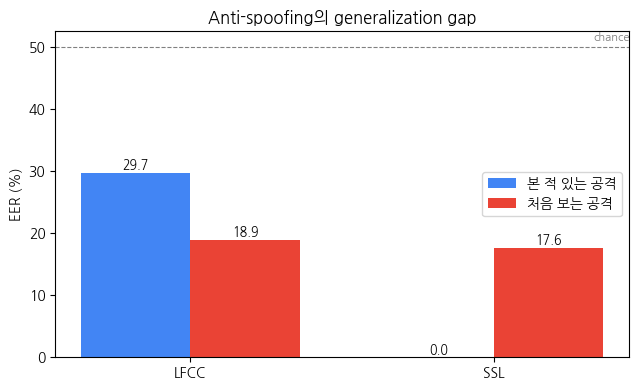

In [21]:
fig, ax = plt.subplots(figsize=(6.5, 4))

names = list(results)
x = np.arange(len(names))
seen = [results[n]["eer"] * 100 for n in names]
unseen = [gen[n] * 100 for n in names]

ax.bar(x - 0.18, seen, width=0.36, label="본 적 있는 공격", color="#4285F4")
ax.bar(x + 0.18, unseen, width=0.36, label="처음 보는 공격", color="#EA4335")
for xi, (a, b) in enumerate(zip(seen, unseen)):
    ax.text(xi - 0.18, a + 0.6, f"{a:.1f}", ha="center", fontsize=9)
    ax.text(xi + 0.18, b + 0.6, f"{b:.1f}", ha="center", fontsize=9)

ax.axhline(50, ls="--", lw=0.8, c="gray")
ax.text(len(names) - 0.55, 51, "chance", fontsize=8, color="gray", ha="right")
ax.set(xticks=x, xticklabels=names, ylabel="EER (%)",
       title="Anti-spoofing의 generalization gap")
ax.legend()
plt.tight_layout()
plt.show()

두 막대의 차이가 generalization gap입니다. 학습에 포함된 공격에서 낮은 EER을 보이던 CM이 unseen attack에서는 EER이 크게 증가합니다. 이는 CM이 일반적인 bonafide 음성의 특성이 아니라 특정 vocoder의 artifact를 학습했기 때문입니다.

대응 방향은 두 가지입니다. 첫째는 **data**로, 다양한 공격을 학습에 포함하고 codec, 압축, 채널 효과 등으로 augmentation 하여 특정 artifact에 대한 의존을 줄입니다. 둘째는 **representation**으로, bonafide 음성만으로 사전학습된 front-end는 공격이 바뀔 때 성능 저하가 상대적으로 작습니다.